# Sign Language Detection using CNN

**Module:** 6CS012 Artificial Intelligence and Machine Learning  
**Assessment:** Final Portfolio – Part II Vision Task  
**Student:** Aaron Shrestha  
**Notebook:** Image Classification using CNN, Deeper CNN, Optimizer Comparison, Ablation Study, and Transfer Learning

## Project Aim

This notebook builds an end-to-end image classification system for sign language gesture detection.

The notebook includes:

1. Google Drive dataset loading and extraction  
2. Automatic Train/Test folder detection  
3. Corrupted/non-image file cleaning  
4. Dataset statistics and class distribution  
5. Image visualization and augmentation  
6. Baseline CNN from scratch  
7. Deeper CNN with Batch Normalization and Dropout  
8. Optimizer comparison: Adam vs SGD  
9. Ablation study: deeper CNN without Dropout  
10. Transfer learning using MobileNetV2  
11. Optional fine-tuning  
12. Evaluation using accuracy, precision, recall, F1-score, classification report, and confusion matrix  
13. Final comparison table and viva notes  

> Run this notebook in **Google Colab with GPU** enabled: Runtime → Change runtime type → T4 GPU.


## 1. Import Required Libraries

In [4]:
import os
import time
import shutil
import zipfile
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import (
    classification_report, confusion_matrix,
    precision_score, recall_score, f1_score
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))


TensorFlow version: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Mount Google Drive, Copy ZIP to Colab, and Extract Dataset

This is the efficient method: keep the ZIP in Google Drive, copy it to `/content`, extract inside `/content`, and train from `/content`.

Expected Drive file path:

```text
/content/drive/MyDrive/Sign_Language_Detection_Dataset.zip
```


In [5]:
from google.colab import drive
drive.mount("/content/drive")

# Change this only if your ZIP file name/location is different.
DRIVE_ZIP_PATH = "/content/drive/MyDrive/Sign_Language_Detection_Dataset.zip"

LOCAL_ZIP_PATH = "/content/Sign_Language_Detection_Dataset.zip"
EXTRACT_DIR = "/content/sign_language_dataset"

if not os.path.exists(DRIVE_ZIP_PATH):
    raise FileNotFoundError(
        f"ZIP file was not found at: {DRIVE_ZIP_PATH}\n"
        "Check the exact file name in Google Drive. "
        "In your screenshot, the file was named Sign_Language_Detection_Dataset.zip"
    )

if not os.path.exists(LOCAL_ZIP_PATH):
    print("Copying ZIP from Google Drive to Colab local storage...")
    shutil.copy(DRIVE_ZIP_PATH, LOCAL_ZIP_PATH)
    print("ZIP copied successfully.")
else:
    print("ZIP already exists in Colab local storage.")

if not os.path.exists(EXTRACT_DIR) or len(os.listdir(EXTRACT_DIR)) == 0:
    print("Extracting dataset...")
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Dataset extracted successfully.")
else:
    print("Dataset already extracted.")

print("Extraction directory:", EXTRACT_DIR)

print("\nExtracted folder preview:")
for root, dirs, files in os.walk(EXTRACT_DIR):
    print("Root:", root)
    print("Folders:", dirs[:10])
    print("Files:", files[:5])
    print("-" * 60)
    if root.count(os.sep) > EXTRACT_DIR.count(os.sep) + 2:
        break


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
ZIP already exists in Colab local storage.
Dataset already extracted.
Extraction directory: /content/sign_language_dataset

Extracted folder preview:
Root: /content/sign_language_dataset
Folders: ['Sign Language Detection']
Files: []
------------------------------------------------------------
Root: /content/sign_language_dataset/Sign Language Detection
Folders: ['Test', 'Train']
Files: ['Dataset-Description-6.txt']
------------------------------------------------------------
Root: /content/sign_language_dataset/Sign Language Detection/Test
Folders: []
Files: ['20180625_203333.jpg', '20180701_194331.jpg', '20180625_230047.jpg']
------------------------------------------------------------
Root: /content/sign_language_dataset/Sign Language Detection/Train
Folders: ['34', '2', '27', '8', '19', '17', '33', '30', '7', '5']
Files: []
-------------------------------

## 3. Automatically Detect Train and Test Directories

This cell finds folders like `Train`, `train`, `Test`, or `test`.  
If the test folder has no images, the notebook will use the validation set for evaluation.


In [6]:
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp", ".gif")

def count_images_inside(directory):
    total = 0
    if directory is None or not os.path.exists(directory):
        return 0
    for root, dirs, files in os.walk(directory):
        total += sum(1 for f in files if f.lower().endswith(VALID_EXTENSIONS))
    return total

def find_candidate_dirs(base_dir, names):
    candidates = []
    allowed_names = [name.lower() for name in names]
    for root, dirs, files in os.walk(base_dir):
        for d in dirs:
            if d.lower() in allowed_names:
                full_path = os.path.join(root, d)
                img_count = count_images_inside(full_path)
                candidates.append((full_path, img_count))
    candidates = sorted(candidates, key=lambda x: x[1], reverse=True)
    return candidates

train_candidates = find_candidate_dirs(EXTRACT_DIR, ["train", "training"])
test_candidates = find_candidate_dirs(EXTRACT_DIR, ["test", "testing", "validation", "valid"])

print("Train candidates:")
for path, count in train_candidates:
    print(count, "images ->", path)

print("\nTest candidates:")
for path, count in test_candidates:
    print(count, "images ->", path)

TRAIN_DIR = train_candidates[0][0] if len(train_candidates) > 0 else None
TEST_DIR = test_candidates[0][0] if len(test_candidates) > 0 and test_candidates[0][1] > 0 else None

if TRAIN_DIR is None:
    raise FileNotFoundError("Train folder was not found. Check the extracted dataset structure.")

print("\nSelected TRAIN_DIR:", TRAIN_DIR)
print("Selected TEST_DIR :", TEST_DIR)

if TEST_DIR is None:
    print("\nWarning: Test folder was not found or has 0 images.")
    print("The notebook will evaluate final models using the validation generator instead.")


Train candidates:
11058 images -> /content/sign_language_dataset/Sign Language Detection/Train

Test candidates:
3 images -> /content/sign_language_dataset/Sign Language Detection/Test

Selected TRAIN_DIR: /content/sign_language_dataset/Sign Language Detection/Train
Selected TEST_DIR : /content/sign_language_dataset/Sign Language Detection/Test


## 4. Clean Corrupted or Non-Image Files

This fixes `UnidentifiedImageError: cannot identify image file`.  
It removes hidden files, non-image files, and corrupted images before Keras creates generators.


In [7]:
def find_bad_images(directory):
    bad_files = []
    if directory is None or not os.path.exists(directory):
        return bad_files

    for root, dirs, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)

            if file.startswith(".") or file.lower() in ["thumbs.db", "desktop.ini"]:
                bad_files.append(file_path)
                continue

            if not file.lower().endswith(VALID_EXTENSIONS):
                bad_files.append(file_path)
                continue

            try:
                with Image.open(file_path) as img:
                    img.verify()
            except Exception:
                bad_files.append(file_path)

    return bad_files

bad_files = find_bad_images(TRAIN_DIR) + find_bad_images(TEST_DIR)

print("Bad/non-image/corrupted files found:", len(bad_files))
for file_path in bad_files[:50]:
    print(file_path)

for file_path in bad_files:
    try:
        os.remove(file_path)
    except Exception as e:
        print("Could not remove:", file_path, "| Error:", e)

print("Cleaning complete.")
print("Training images after cleaning:", count_images_inside(TRAIN_DIR))
if TEST_DIR:
    print("Testing images after cleaning:", count_images_inside(TEST_DIR))


Bad/non-image/corrupted files found: 266
/content/sign_language_dataset/Sign Language Detection/Train/34/20180702_101754.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/IMG_20180718_131942.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/IMG_20180716_093326.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/IMG_20180718_163843.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/DSC_1740.JPG
/content/sign_language_dataset/Sign Language Detection/Train/34/IMG_20180630_080026.jpg
/content/sign_language_dataset/Sign Language Detection/Train/34/20180707_004013.jpg
/content/sign_language_dataset/Sign Language Detection/Train/2/IMG_20180715_102251.jpg
/content/sign_language_dataset/Sign Language Detection/Train/2/IMG_20180702_103836.jpg
/content/sign_language_dataset/Sign Language Detection/Train/2/DSC_0827.JPG
/content/sign_language_dataset/Sign Language Detection/Train/2/IMG_20180626_110709.jpg
/content/sign_language_da

## 5. Dataset Statistics and Class Distribution

Number of classes in training set: 38
Total training images: 10792


,class,count
0,0,286
1,1,287
2,10,291
3,11,284
4,12,277


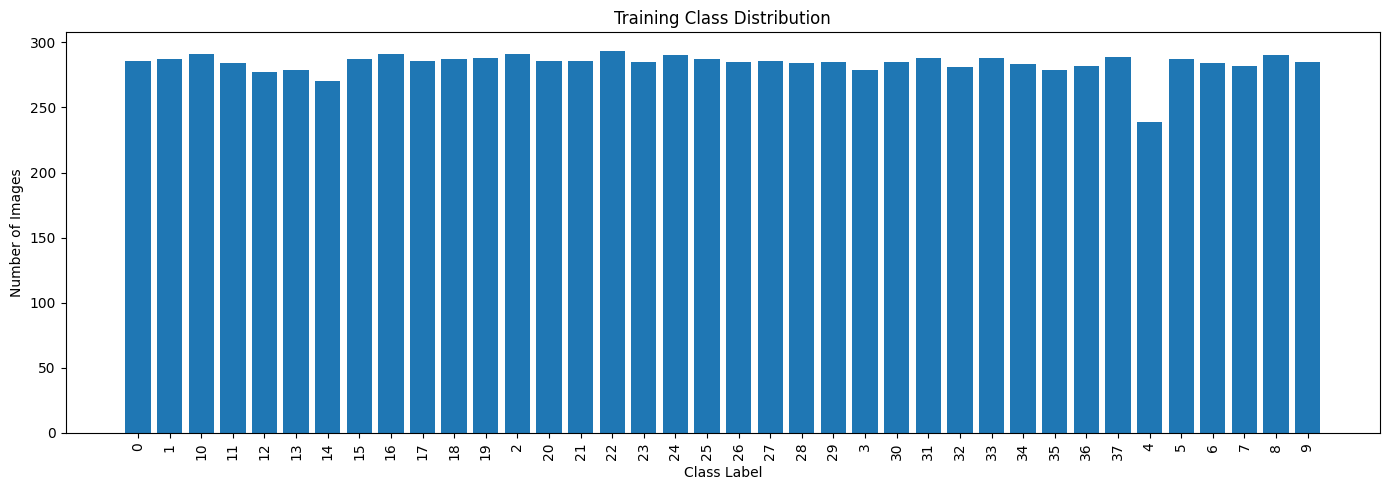

count     38.000000
mean     284.000000
std        8.708492
min      239.000000
25%      283.250000
50%      286.000000
75%      287.750000
max      293.000000
Name: count, dtype: float64


In [8]:
def class_distribution(directory):
    records = []
    class_names = sorted([
        d for d in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, d))
    ])

    for class_name in class_names:
        class_path = os.path.join(directory, class_name)
        count = sum(
            1 for f in os.listdir(class_path)
            if f.lower().endswith(VALID_EXTENSIONS)
        )
        records.append({"class": class_name, "count": count})

    return pd.DataFrame(records)

train_class_df = class_distribution(TRAIN_DIR)
print("Number of classes in training set:", len(train_class_df))
print("Total training images:", train_class_df["count"].sum())
display(train_class_df.head())

plt.figure(figsize=(14, 5))
plt.bar(train_class_df["class"], train_class_df["count"])
plt.title("Training Class Distribution")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

print(train_class_df["count"].describe())


## 6. Visualize Sample Images

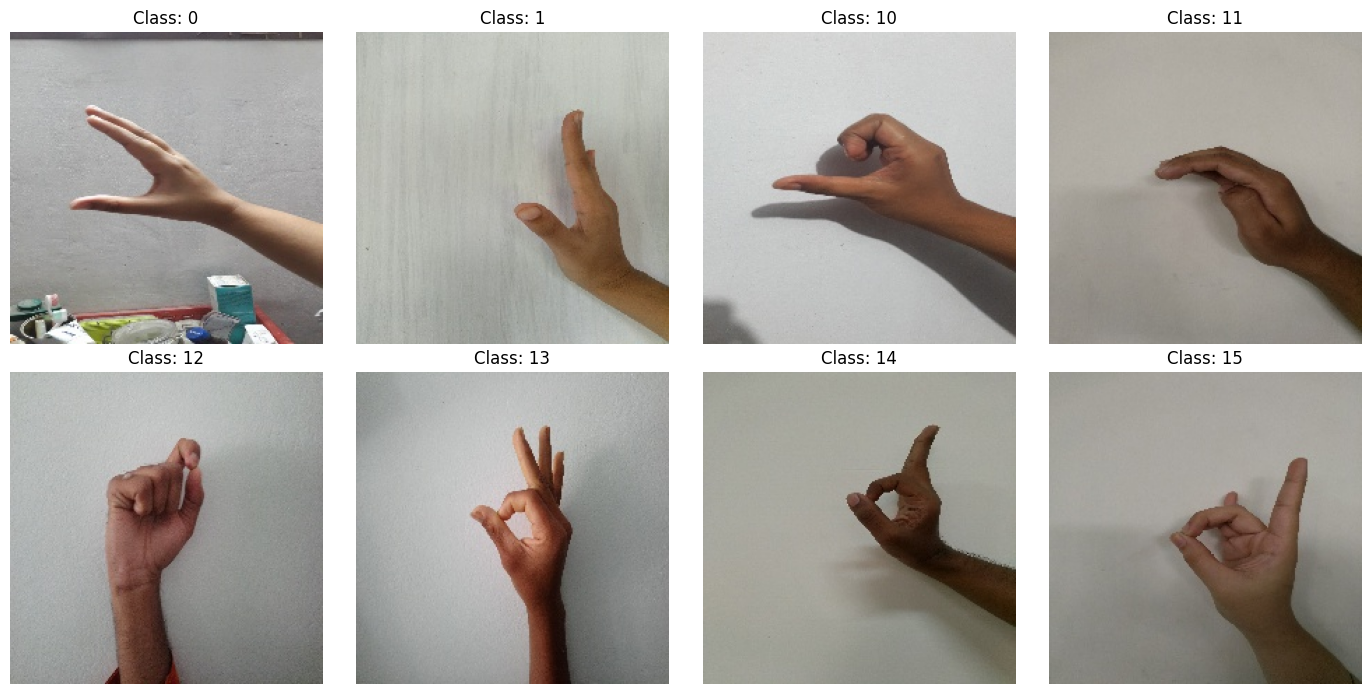

In [9]:
def show_sample_images(directory, num_classes=8):
    class_names = sorted([
        d for d in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, d))
    ])

    selected_classes = class_names[:num_classes]

    plt.figure(figsize=(14, 7))
    for i, class_name in enumerate(selected_classes):
        class_path = os.path.join(directory, class_name)
        images = [
            f for f in os.listdir(class_path)
            if f.lower().endswith(VALID_EXTENSIONS)
        ]

        if len(images) == 0:
            continue

        image_path = os.path.join(class_path, random.choice(images))
        img = Image.open(image_path).convert("RGB")

        plt.subplot(2, 4, i + 1)
        plt.imshow(img)
        plt.title(f"Class: {class_name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_sample_images(TRAIN_DIR, num_classes=8)


## 7. Global Configuration

In [10]:
IMG_SIZE = (128, 128)
BATCH_SIZE = 32

EPOCHS_BASELINE = 25
EPOCHS_DEEPER = 30
EPOCHS_TRANSFER = 15
EPOCHS_FINE_TUNE = 10

print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Baseline epochs:", EPOCHS_BASELINE)
print("Deeper CNN epochs:", EPOCHS_DEEPER)
print("Transfer learning epochs:", EPOCHS_TRANSFER)
print("Fine tuning epochs:", EPOCHS_FINE_TUNE)


Image size: (128, 128)
Batch size: 32
Baseline epochs: 25
Deeper CNN epochs: 30
Transfer learning epochs: 15
Fine tuning epochs: 10


## 8. Create Data Generators

Training data uses augmentation. Validation data is only rescaled.  
If there is no usable test folder, final evaluation uses the validation set.


In [11]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.15
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

val_generator = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

def has_class_subfolders(directory):
    """Return True only if a directory contains class-wise subfolders."""
    if directory is None or not os.path.exists(directory):
        return False

    class_folders = [
        d for d in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, d))
    ]

    return len(class_folders) > 0


if TEST_DIR is not None and has_class_subfolders(TEST_DIR):
    test_generator = test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )
    evaluation_generator = test_generator
    evaluation_name = "Test Set"
else:
    test_generator = None
    evaluation_generator = val_generator
    evaluation_name = "Validation Set"
    print("Test folder exists, but it is not class-wise or has no class folders.")
    print("Using validation set for metric-based evaluation.")


NUM_CLASSES = train_generator.num_classes
class_indices = train_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

print("Number of classes:", NUM_CLASSES)
print("Evaluation will use:", evaluation_name)
print("Class mapping:", class_indices)


Found 9194 images belonging to 38 classes.
Found 1598 images belonging to 38 classes.
Test folder exists, but it is not class-wise or has no class folders.
Using validation set for metric-based evaluation.
Number of classes: 38
Evaluation will use: Validation Set
Class mapping: {'0': 0, '1': 1, '10': 2, '11': 3, '12': 4, '13': 5, '14': 6, '15': 7, '16': 8, '17': 9, '18': 10, '19': 11, '2': 12, '20': 13, '21': 14, '22': 15, '23': 16, '24': 17, '25': 18, '26': 19, '27': 20, '28': 21, '29': 22, '3': 23, '30': 24, '31': 25, '32': 26, '33': 27, '34': 28, '35': 29, '36': 30, '37': 31, '4': 32, '5': 33, '6': 34, '7': 35, '8': 36, '9': 37}


## 9. Visualize Augmented Training Images

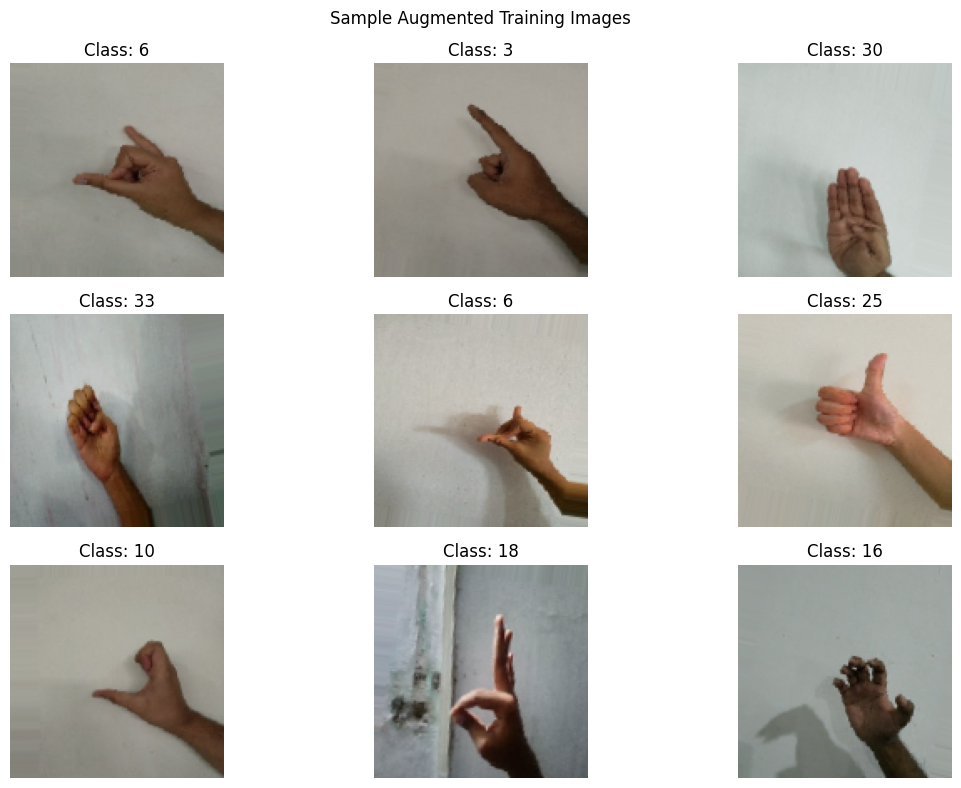

In [12]:
images, labels = next(train_generator)

plt.figure(figsize=(12, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    plt.imshow(images[i])
    label_idx = int(np.argmax(labels[i]))
    plt.title(f"Class: {idx_to_class[label_idx]}")
    plt.axis("off")

plt.suptitle("Sample Augmented Training Images")
plt.tight_layout()
plt.show()


## 10. Helper Functions

`get_callbacks()` creates fresh callbacks for every model.  
This prevents old callback state from affecting later model training.


In [13]:
def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.3,
            patience=3,
            min_lr=1e-6
        )
    ]

def plot_training_curves(history, title):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

def plot_confusion_matrix(cm, class_labels, title):
    plt.figure(figsize=(14, 12))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(class_labels))
    plt.xticks(tick_marks, class_labels, rotation=90)
    plt.yticks(tick_marks, class_labels)

    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.tight_layout()
    plt.show()

def evaluate_model(model, generator, model_name):
    generator.reset()

    y_prob = model.predict(generator, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)
    y_true = generator.classes

    accuracy = np.mean(y_pred == y_true)
    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    print("\n" + "=" * 60)
    print(f"{model_name} Evaluation Results on {evaluation_name}")
    print("=" * 60)
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    labels = list(generator.class_indices.keys())

    print("\nClassification Report:")
    print(classification_report(
        y_true,
        y_pred,
        target_names=labels,
        zero_division=0
    ))

    cm = confusion_matrix(y_true, y_pred)
    plot_confusion_matrix(cm, labels, f"{model_name} - Confusion Matrix")

    return {
        "model": model_name,
        "evaluation_set": evaluation_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }


# Part A: CNN Models from Scratch

## 11. Baseline CNN Model

Assignment requirement: 3 convolutional layers, pooling layers, 3 fully connected layers, and an output layer.


In [14]:
def build_baseline_cnn(num_classes, input_shape=(128, 128, 3)):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", input_shape=input_shape),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu"),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation="relu"),
        Dropout(0.5),

        Dense(128, activation="relu"),
        Dropout(0.3),

        Dense(64, activation="relu"),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

baseline_model = build_baseline_cnn(
    num_classes=NUM_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

baseline_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,559,654 (25.02 MB)

 Trainable params: 6,559,654 (25.02 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Train Baseline CNN

In [15]:
print("Training Baseline CNN...")
start_time = time.time()

history_baseline = baseline_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_BASELINE,
    callbacks=get_callbacks()
)

baseline_time = time.time() - start_time
print(f"Baseline CNN training time: {baseline_time:.2f} seconds")


Training Baseline CNN...
Epoch 1/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 65s 198ms/step - accuracy: 0.0240 - loss: 3.6392 - val_accuracy: 0.0263 - val_loss: 3.6374 - learning_rate: 0.0010
Epoch 2/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.0359 - loss: 3.5993 - val_accuracy: 0.0901 - val_loss: 3.4207 - learning_rate: 0.0010
Epoch 3/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 175ms/step - accuracy: 0.1082 - loss: 3.3061 - val_accuracy: 0.1702 - val_loss: 2.9336 - learning_rate: 0.0010
Epoch 4/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 178ms/step - accuracy: 0.2122 - loss: 2.7357 - val_accuracy: 0.3417 - val_loss: 2.2582 - learning_rate: 0.0010
Epoch 5/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 173ms/step - accuracy: 0.3109 - loss: 2.2932 - val_accuracy: 0.3955 - val_loss: 2.0281 - learning_rate: 0.0010
Epoch 6/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 56s 193ms/step - accuracy: 0.3771 - loss: 2.0174 - val_accuracy: 0.4681 - val_loss: 1.7770 - learning_rate: 0.0010
Epoch 7/25
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 1

## 13. Evaluate Baseline CNN

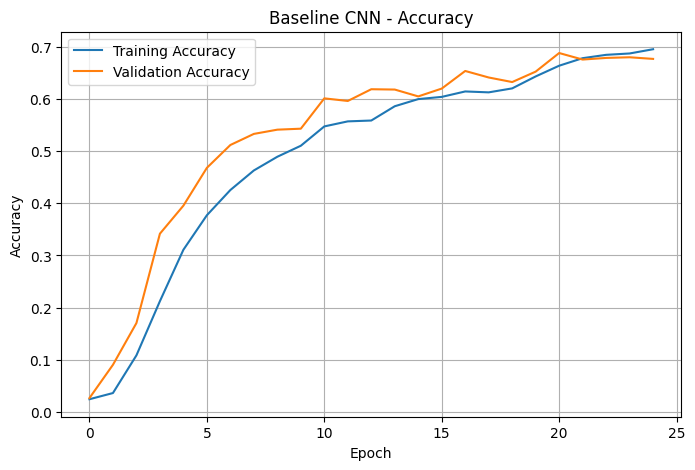

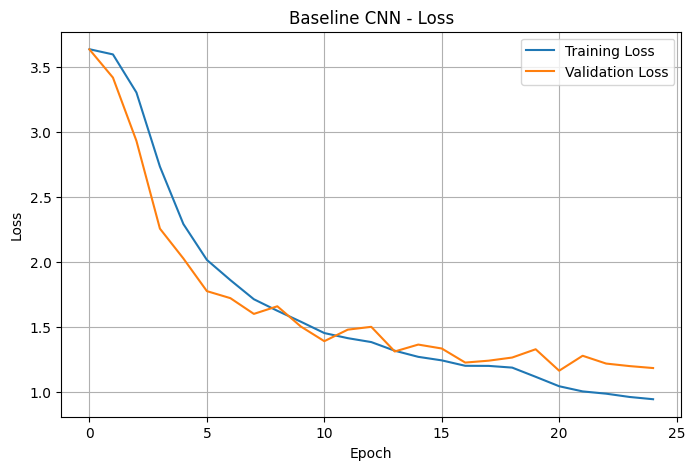

50/50 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step

Baseline CNN Evaluation Results on Validation Set
Accuracy : 0.6884
Precision: 0.6975
Recall   : 0.6884
F1-score : 0.6870

Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.69      0.67        42
           1       0.70      0.70      0.70        43
          10       0.70      0.65      0.67        43
          11       0.76      0.81      0.78        42
          12       0.78      0.76      0.77        41
          13       0.60      0.59      0.59        41
          14       0.85      0.55      0.67        40
          15       0.91      0.49      0.64        43
          16       0.64      0.84      0.73        43
          17       0.75      0.71      0.73        42
          18       0.52      0.58      0.55        43
          19       0.38      0.40      0.39        43
           2       0.86      0.84      0.85        43
          20       0.63      0.69      0.66        42
  

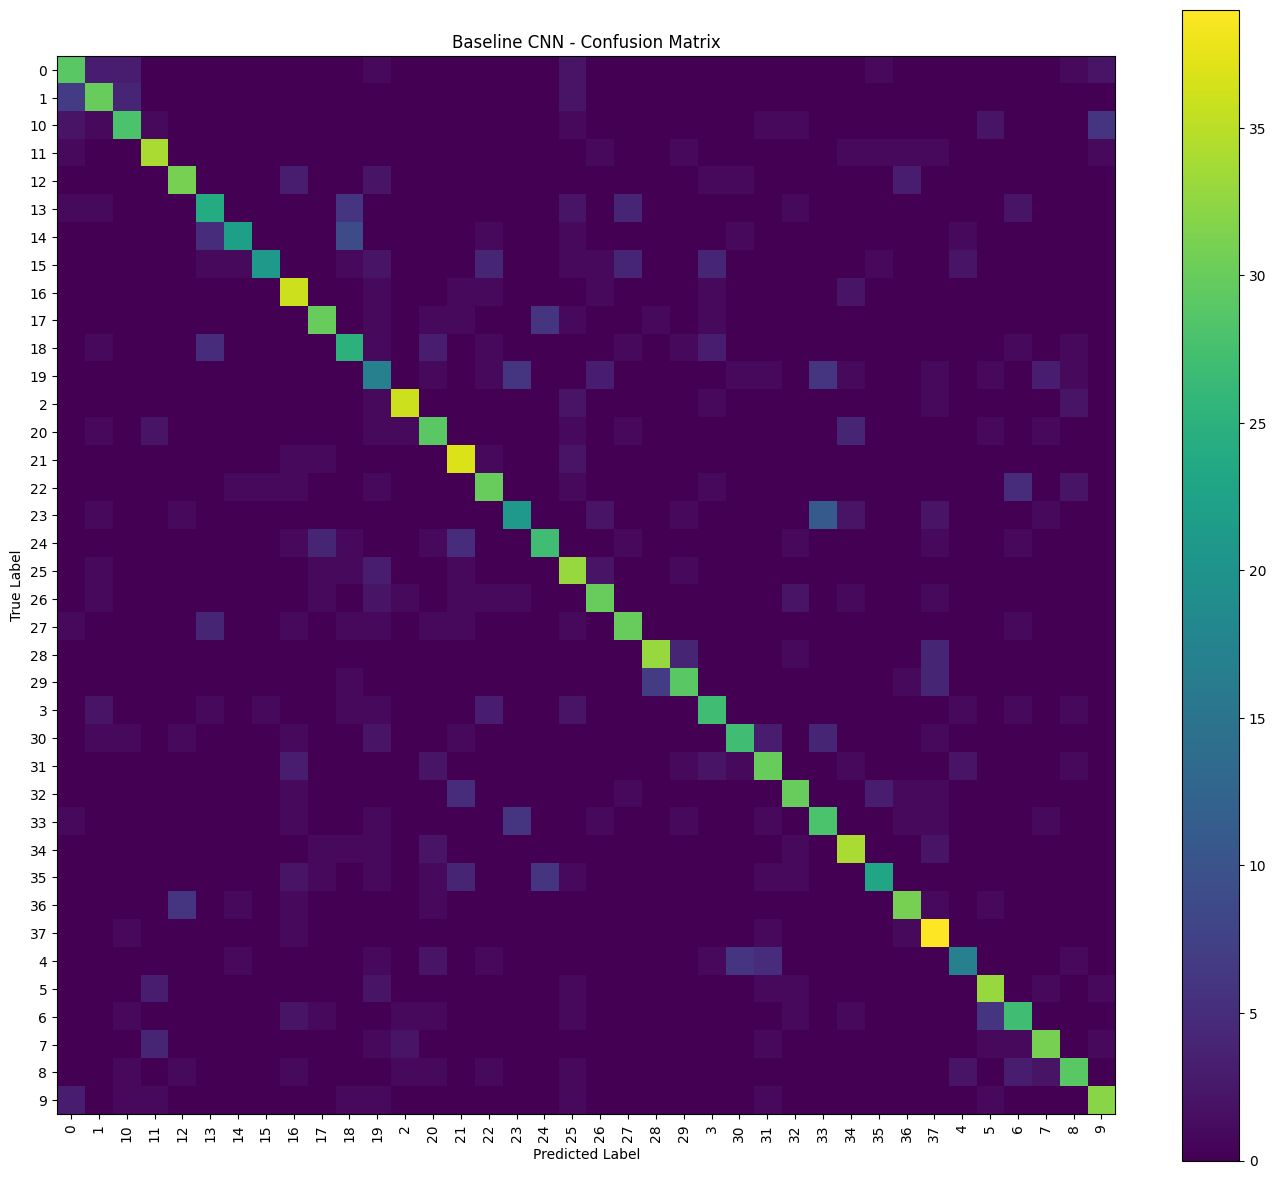

In [16]:
plot_training_curves(history_baseline, "Baseline CNN")
baseline_results = evaluate_model(baseline_model, evaluation_generator, "Baseline CNN")


## 14. Deeper CNN with Batch Normalization and Dropout

This model has at least double the convolutional layers compared to the baseline model.


In [17]:
def build_deeper_cnn(num_classes, input_shape=(128, 128, 3), optimizer_name="adam"):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.25),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.30),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.40),

        Flatten(),

        Dense(256, activation="relu"),
        BatchNormalization(),
        Dropout(0.50),

        Dense(128, activation="relu"),
        BatchNormalization(),
        Dropout(0.40),

        Dense(num_classes, activation="softmax")
    ])

    if optimizer_name.lower() == "adam":
        optimizer = Adam(learning_rate=0.001)
    elif optimizer_name.lower() == "sgd":
        optimizer = SGD(learning_rate=0.01, momentum=0.9)
    else:
        raise ValueError("optimizer_name must be either 'adam' or 'sgd'")

    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

deeper_adam_model = build_deeper_cnn(
    num_classes=NUM_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    optimizer_name="adam"
)

deeper_adam_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 8,716,998 (33.25 MB)

 Trainable params: 8,715,334 (33.25 MB)

 Non-trainable params: 1,664 (6.50 KB)

## 15. Train Deeper CNN with Adam

In [18]:
print("Training Deeper CNN with Adam...")
start_time = time.time()

history_deeper_adam = deeper_adam_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_DEEPER,
    callbacks=get_callbacks()
)

deeper_adam_time = time.time() - start_time
print(f"Deeper CNN with Adam training time: {deeper_adam_time:.2f} seconds")


Training Deeper CNN with Adam...
Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 88s 238ms/step - accuracy: 0.0584 - loss: 4.0564 - val_accuracy: 0.0225 - val_loss: 4.5980 - learning_rate: 0.0010
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 178ms/step - accuracy: 0.0980 - loss: 3.5320 - val_accuracy: 0.1527 - val_loss: 3.1218 - learning_rate: 0.0010
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 53s 184ms/step - accuracy: 0.1551 - loss: 3.1395 - val_accuracy: 0.2165 - val_loss: 2.9411 - learning_rate: 0.0010
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.2332 - loss: 2.7251 - val_accuracy: 0.3179 - val_loss: 2.4675 - learning_rate: 0.0010
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.3311 - loss: 2.3047 - val_accuracy: 0.2040 - val_loss: 2.8586 - learning_rate: 0.0010
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 180ms/step - accuracy: 0.4057 - loss: 2.0045 - val_accuracy: 0.4568 - val_loss: 1.7947 - learning_rate: 0.0010
Epoch 7/30
288/288 ━━━━━━━━━━━━━━━━━━

## 16. Evaluate Deeper CNN with Adam

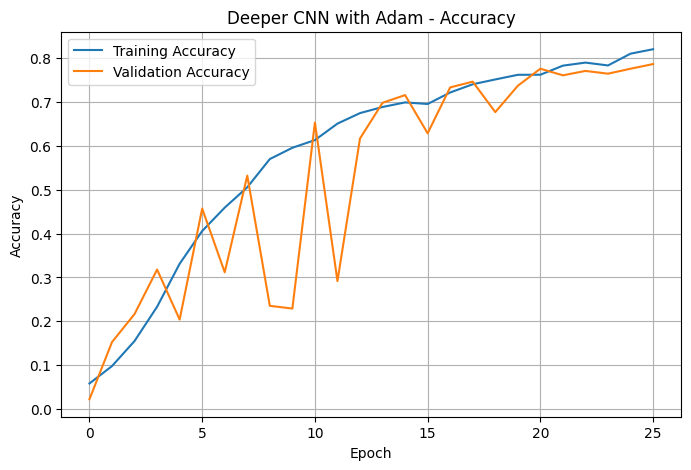

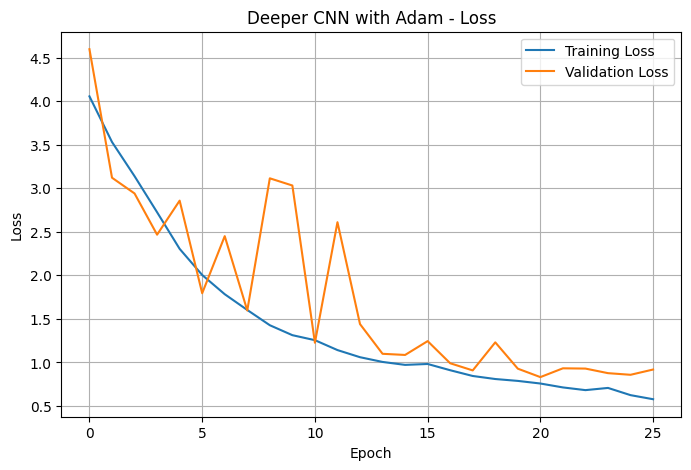

50/50 ━━━━━━━━━━━━━━━━━━━━ 4s 48ms/step

Deeper CNN with Adam Evaluation Results on Validation Set
Accuracy : 0.7753
Precision: 0.8010
Recall   : 0.7753
F1-score : 0.7780

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.74      0.77        42
           1       0.88      0.84      0.86        43
          10       0.92      0.77      0.84        43
          11       0.85      0.79      0.81        42
          12       0.79      0.80      0.80        41
          13       0.76      0.85      0.80        41
          14       0.97      0.70      0.81        40
          15       0.94      0.77      0.85        43
          16       0.90      0.88      0.89        43
          17       0.97      0.86      0.91        42
          18       0.71      0.79      0.75        43
          19       0.81      0.60      0.69        43
           2       0.62      0.88      0.73        43
          20       0.71      0.76      0.74     

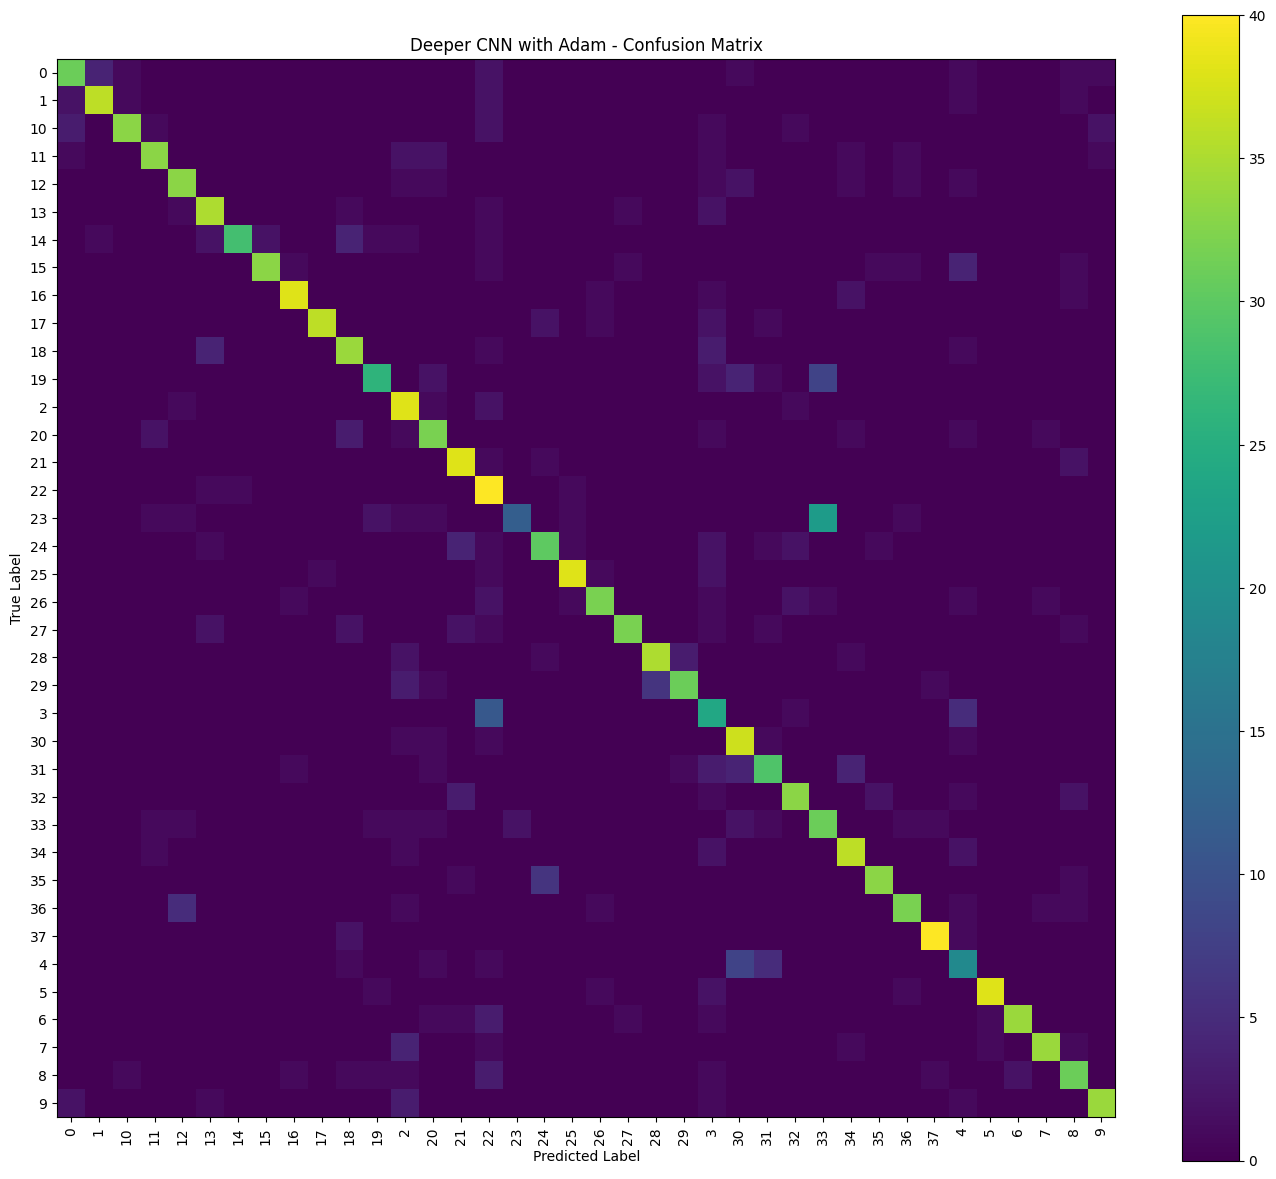

In [19]:
plot_training_curves(history_deeper_adam, "Deeper CNN with Adam")
deeper_adam_results = evaluate_model(deeper_adam_model, evaluation_generator, "Deeper CNN with Adam")


## 17. Optimizer Comparison: Deeper CNN with SGD

In [20]:
deeper_sgd_model = build_deeper_cnn(
    num_classes=NUM_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
    optimizer_name="sgd"
)

print("Training Deeper CNN with SGD...")
start_time = time.time()

history_deeper_sgd = deeper_sgd_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_DEEPER,
    callbacks=get_callbacks()
)

deeper_sgd_time = time.time() - start_time
print(f"Deeper CNN with SGD training time: {deeper_sgd_time:.2f} seconds")


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training Deeper CNN with SGD...
Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 72s 211ms/step - accuracy: 0.0581 - loss: 3.9124 - val_accuracy: 0.0676 - val_loss: 3.8512 - learning_rate: 0.0100
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 182ms/step - accuracy: 0.0931 - loss: 3.4486 - val_accuracy: 0.1014 - val_loss: 3.3719 - learning_rate: 0.0100
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.1261 - loss: 3.2176 - val_accuracy: 0.1502 - val_loss: 3.2162 - learning_rate: 0.0100
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 52s 181ms/step - accuracy: 0.1918 - loss: 2.8462 - val_accuracy: 0.1008 - val_loss: 3.5276 - learning_rate: 0.0100
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 174ms/step - accuracy: 0.2693 - loss: 2.4979 - val_accuracy: 0.3648 - val_loss: 2.2519 - learning_rate: 0.0100
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 56s 194ms/step - accuracy: 0.3407 - loss: 2.1999 - val_accuracy: 0.1133 - val_loss: 3.3023 - learning_rate: 0.0100
Epoch 7/30
288/288 ━━━━━━━━━━━━━━━━━━━

## 18. Evaluate Deeper CNN with SGD

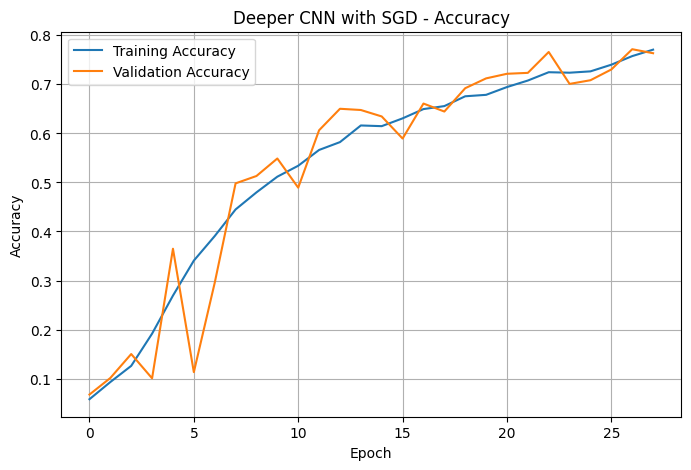

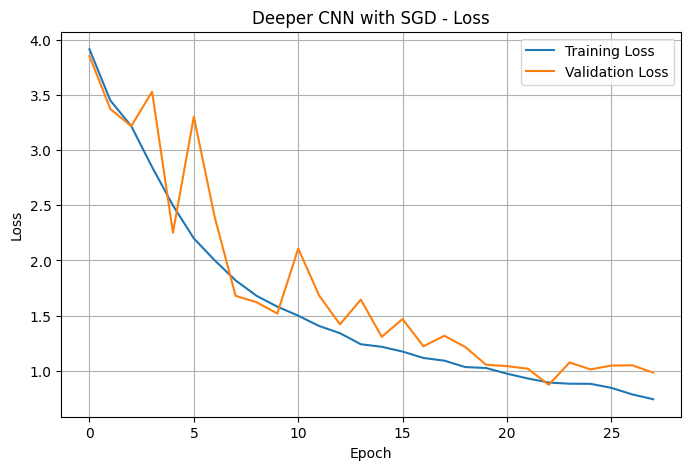

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step

Deeper CNN with SGD Evaluation Results on Validation Set
Accuracy : 0.7660
Precision: 0.7962
Recall   : 0.7660
F1-score : 0.7742

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.74      0.74        42
           1       0.86      0.86      0.86        43
          10       0.91      0.74      0.82        43
          11       0.79      0.81      0.80        42
          12       0.76      0.83      0.79        41
          13       0.80      0.78      0.79        41
          14       0.83      0.72      0.77        40
          15       0.85      0.67      0.75        43
          16       0.86      0.84      0.85        43
          17       0.94      0.81      0.87        42
          18       0.82      0.72      0.77        43
          19       0.79      0.72      0.76        43
           2       0.75      0.88      0.81        43
          20       0.74      0.83      0.79      

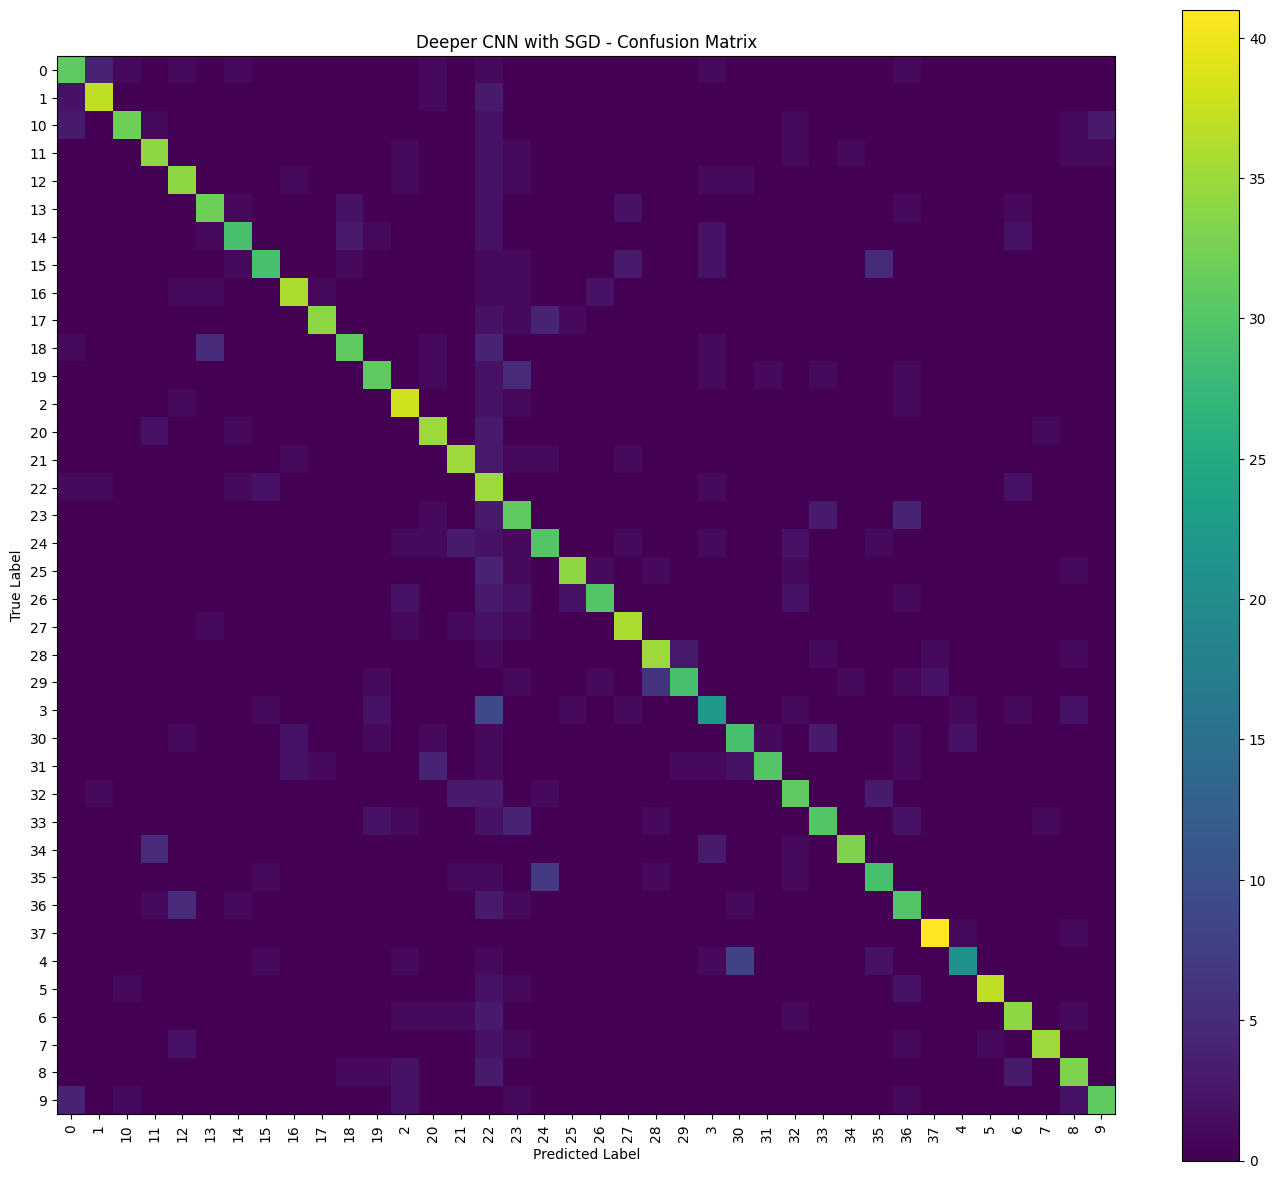

In [21]:
plot_training_curves(history_deeper_sgd, "Deeper CNN with SGD")
deeper_sgd_results = evaluate_model(deeper_sgd_model, evaluation_generator, "Deeper CNN with SGD")


## 19. Ablation Study: Deeper CNN without Dropout

In [22]:
def build_deeper_without_dropout(num_classes, input_shape=(128, 128, 3)):
    model = Sequential([
        Conv2D(32, (3, 3), activation="relu", padding="same", input_shape=input_shape),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        BatchNormalization(),
        MaxPooling2D((2, 2)),

        Flatten(),

        Dense(256, activation="relu"),
        BatchNormalization(),

        Dense(128, activation="relu"),
        BatchNormalization(),

        Dense(num_classes, activation="softmax")
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

ablation_model = build_deeper_without_dropout(
    num_classes=NUM_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

ablation_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_20          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_21          │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_22          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_23          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 38)             │         4,90

 Total params: 8,716,998 (33.25 MB)

 Trainable params: 8,715,334 (33.25 MB)

 Non-trainable params: 1,664 (6.50 KB)

## 20. Train Ablation Model

In [23]:
print("Training Ablation Model without Dropout...")
start_time = time.time()

history_ablation = ablation_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS_DEEPER,
    callbacks=get_callbacks()
)

ablation_time = time.time() - start_time
print(f"Ablation model training time: {ablation_time:.2f} seconds")


Training Ablation Model without Dropout...
Epoch 1/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 67s 197ms/step - accuracy: 0.1763 - loss: 3.1473 - val_accuracy: 0.0263 - val_loss: 15.8364 - learning_rate: 0.0010
Epoch 2/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 50s 173ms/step - accuracy: 0.4305 - loss: 1.9965 - val_accuracy: 0.1158 - val_loss: 3.8857 - learning_rate: 0.0010
Epoch 3/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.5752 - loss: 1.4427 - val_accuracy: 0.5732 - val_loss: 1.4513 - learning_rate: 0.0010
Epoch 4/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 177ms/step - accuracy: 0.6844 - loss: 1.0699 - val_accuracy: 0.6095 - val_loss: 1.3014 - learning_rate: 0.0010
Epoch 5/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 172ms/step - accuracy: 0.7315 - loss: 0.8932 - val_accuracy: 0.5063 - val_loss: 1.6741 - learning_rate: 0.0010
Epoch 6/30
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 178ms/step - accuracy: 0.7629 - loss: 0.7804 - val_accuracy: 0.4274 - val_loss: 2.3516 - learning_rate: 0.0010
Epoch 7/30
288/288 ━━━━━━━

In [24]:
# Save the trained ablation model to Google Drive
# This prevents retraining if you only need predictions later.

ablation_model.save("/content/drive/MyDrive/ablation_sign_language_model.keras")
print("Ablation model saved to Google Drive as ablation_sign_language_model.keras")


Ablation model saved to Google Drive as ablation_sign_language_model.keras


## 21. Evaluate Ablation Model

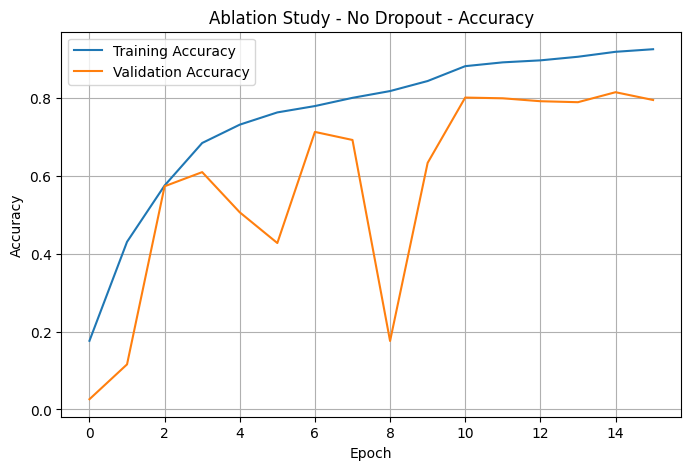

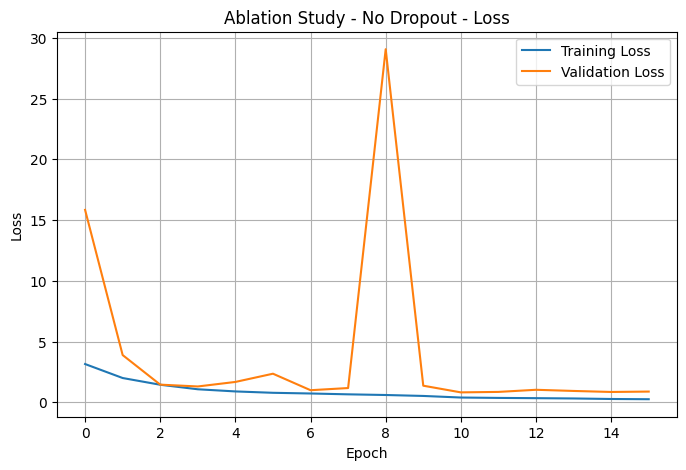

50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step

Ablation Study - No Dropout Evaluation Results on Validation Set
Accuracy : 0.8010
Precision: 0.8438
Recall   : 0.8010
F1-score : 0.8153

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.76      0.74        42
           1       0.87      0.77      0.81        43
          10       0.76      0.79      0.77        43
          11       0.75      0.86      0.80        42
          12       0.87      0.83      0.85        41
          13       0.91      0.76      0.83        41
          14       1.00      0.70      0.82        40
          15       1.00      0.72      0.84        43
          16       0.90      0.86      0.88        43
          17       0.94      0.81      0.87        42
          18       0.80      0.84      0.82        43
          19       0.78      0.74      0.76        43
           2       0.95      0.91      0.93        43
          20       0.82      0.86      0.

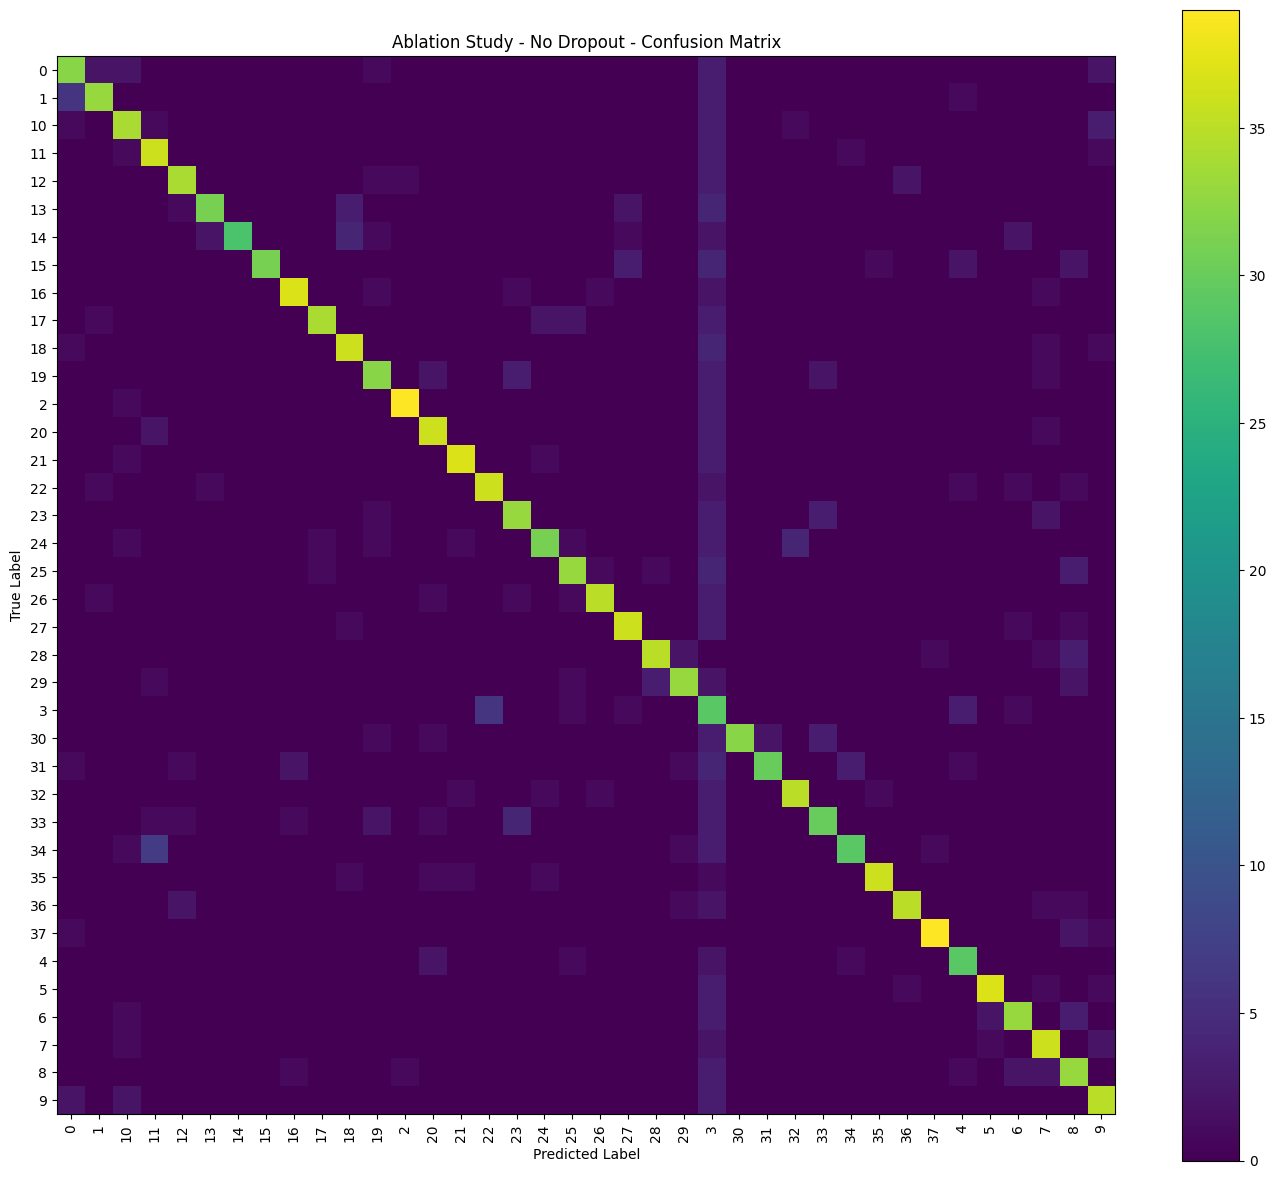

In [25]:
plot_training_curves(history_ablation, "Ablation Study - No Dropout")
ablation_results = evaluate_model(ablation_model, evaluation_generator, "Ablation Study - No Dropout")


# Part B: Transfer Learning

## 22. Create MobileNetV2 Data Generators

In [26]:
transfer_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.15,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.10,
    height_shift_range=0.10,
    shear_range=0.10,
    fill_mode="nearest"
)

transfer_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.15
)

transfer_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

transfer_train_generator = transfer_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="training",
    shuffle=True,
    seed=SEED
)

transfer_val_generator = transfer_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    subset="validation",
    shuffle=False,
    seed=SEED
)

if TEST_DIR is not None and has_class_subfolders(TEST_DIR):
    transfer_test_generator = transfer_test_datagen.flow_from_directory(
        TEST_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode="categorical",
        shuffle=False
    )
    transfer_evaluation_generator = transfer_test_generator
else:
    transfer_test_generator = None
    transfer_evaluation_generator = transfer_val_generator
    print("Transfer learning evaluation will also use validation set because Test folder is not class-wise.")

print("Transfer learning evaluation will use:", evaluation_name)


Found 9194 images belonging to 38 classes.
Found 1598 images belonging to 38 classes.
Transfer learning evaluation will also use validation set because Test folder is not class-wise.
Transfer learning evaluation will use: Validation Set


## 23. Build MobileNetV2 Transfer Learning Model

MobileNetV2 is lightweight and suitable for Colab GPU. The ImageNet convolutional base is frozen first.


In [27]:
def build_transfer_model(num_classes, input_shape=(128, 128, 3)):
    try:
        base_model = MobileNetV2(
            weights="imagenet",
            include_top=False,
            input_shape=input_shape
        )
        print("Loaded MobileNetV2 with ImageNet weights.")
    except Exception as e:
        print("Could not load ImageNet weights. Loading MobileNetV2 without pretrained weights.")
        print("Error:", e)
        base_model = MobileNetV2(
            weights=None,
            include_top=False,
            input_shape=input_shape
        )

    base_model.trainable = False

    inputs = tf.keras.Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.50)(x)
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.30)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs)

    model.compile(
        optimizer=Adam(learning_rate=0.0005),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model, base_model

transfer_model, mobilenet_base = build_transfer_model(
    num_classes=NUM_CLASSES,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)

transfer_model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Loaded MobileNetV2 with ImageNet weights.


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,623,718 (10.01 MB)

 Trainable params: 365,734 (1.40 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 24. Train MobileNetV2 Feature Extraction Model

In [28]:
print("Training MobileNetV2 Feature Extraction Model...")
start_time = time.time()

history_transfer = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=EPOCHS_TRANSFER,
    callbacks=get_callbacks()
)

transfer_time = time.time() - start_time
print(f"Transfer learning training time: {transfer_time:.2f} seconds")


Training MobileNetV2 Feature Extraction Model...
Epoch 1/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 96s 267ms/step - accuracy: 0.1511 - loss: 3.1202 - val_accuracy: 0.4556 - val_loss: 2.0514 - learning_rate: 5.0000e-04
Epoch 2/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 46s 160ms/step - accuracy: 0.3883 - loss: 2.0043 - val_accuracy: 0.5713 - val_loss: 1.4678 - learning_rate: 5.0000e-04
Epoch 3/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 164ms/step - accuracy: 0.4922 - loss: 1.5935 - val_accuracy: 0.6320 - val_loss: 1.2326 - learning_rate: 5.0000e-04
Epoch 4/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 84s 172ms/step - accuracy: 0.5500 - loss: 1.3890 - val_accuracy: 0.6539 - val_loss: 1.1682 - learning_rate: 5.0000e-04
Epoch 5/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 47s 164ms/step - accuracy: 0.5874 - loss: 1.2625 - val_accuracy: 0.6508 - val_loss: 1.1363 - learning_rate: 5.0000e-04
Epoch 6/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 166ms/step - accuracy: 0.6200 - loss: 1.1827 - val_accuracy: 0.6527 - val_loss: 1.0818 - learning_rate: 5.0000e-

## 25. Evaluate MobileNetV2 Feature Extraction Model

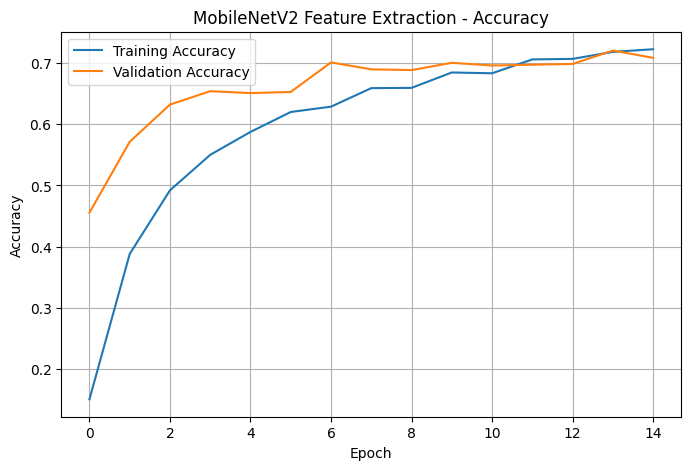

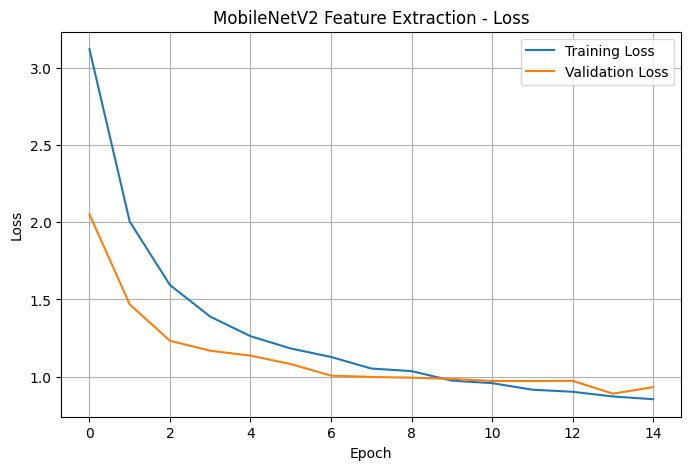

50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 119ms/step

MobileNetV2 Feature Extraction Evaluation Results on Validation Set
Accuracy : 0.7203
Precision: 0.7302
Recall   : 0.7203
F1-score : 0.7170

Classification Report:
              precision    recall  f1-score   support

           0       0.74      0.69      0.72        42
           1       0.65      0.86      0.74        43
          10       0.78      0.74      0.76        43
          11       0.93      0.90      0.92        42
          12       0.67      0.54      0.59        41
          13       0.57      0.78      0.66        41
          14       0.62      0.57      0.60        40
          15       0.55      0.49      0.52        43
          16       0.95      0.86      0.90        43
          17       0.76      0.88      0.81        42
          18       0.61      0.44      0.51        43
          19       0.82      0.65      0.73        43
           2       0.86      0.70      0.77        43
          20       0.73      0.88   

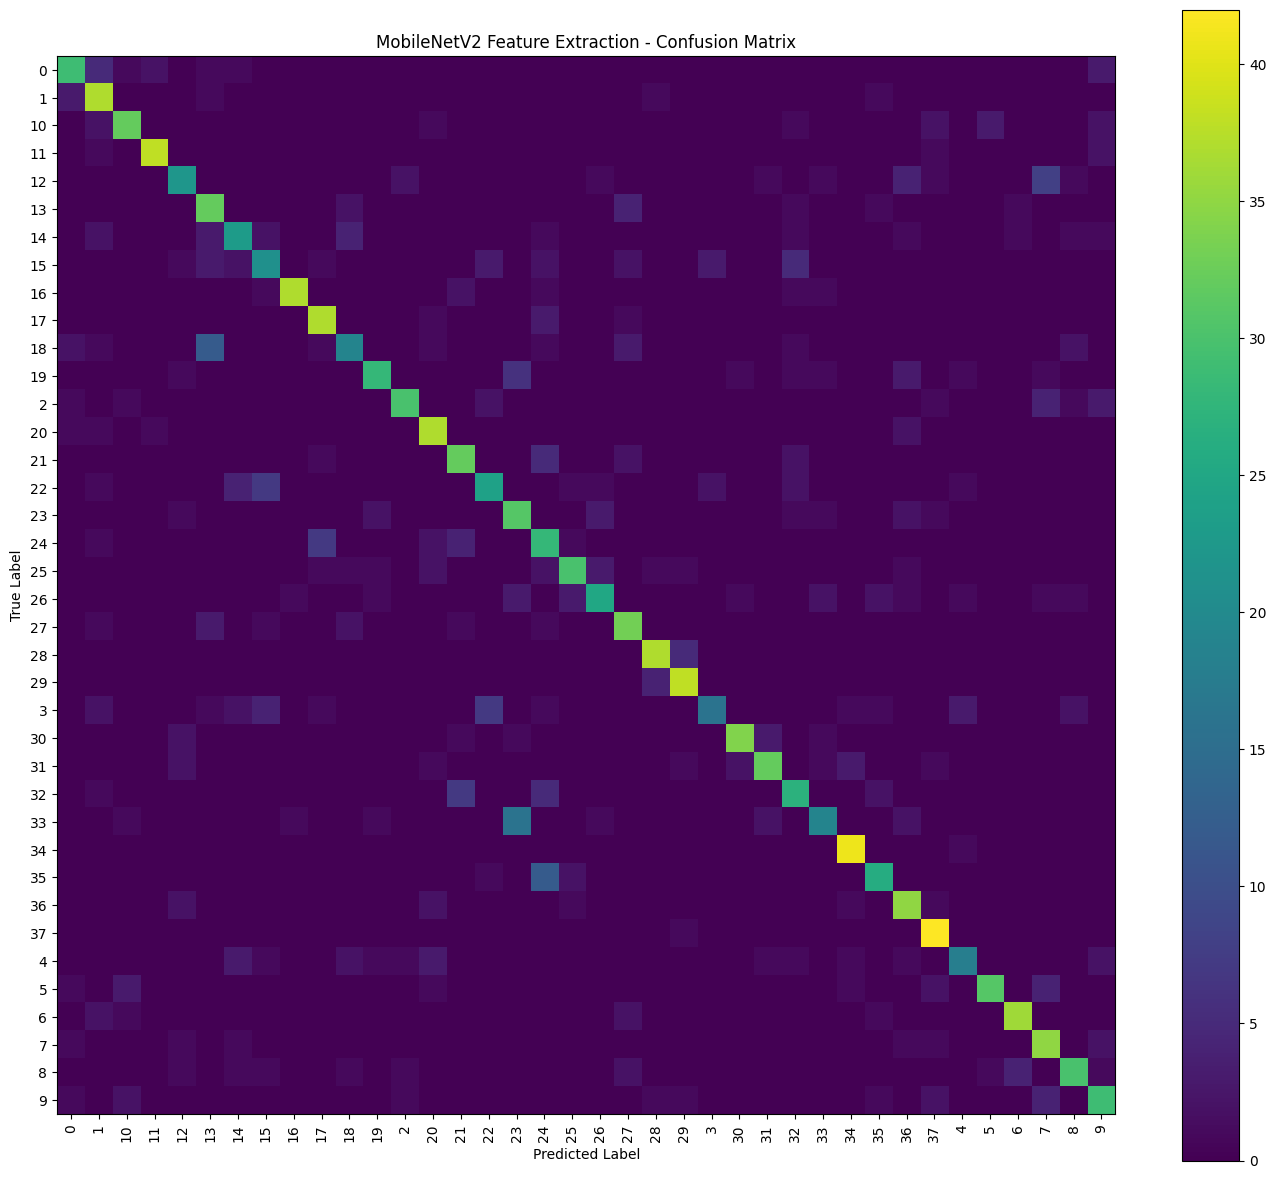

In [29]:
plot_training_curves(history_transfer, "MobileNetV2 Feature Extraction")
transfer_results = evaluate_model(transfer_model, transfer_evaluation_generator, "MobileNetV2 Feature Extraction")


## 26. Optional Fine-Tuning of MobileNetV2

In [30]:
mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False

transfer_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning MobileNetV2...")
start_time = time.time()

history_fine_tune = transfer_model.fit(
    transfer_train_generator,
    validation_data=transfer_val_generator,
    epochs=EPOCHS_FINE_TUNE,
    callbacks=get_callbacks()
)

fine_tune_time = time.time() - start_time
print(f"Fine-tuning training time: {fine_tune_time:.2f} seconds")


Fine-tuning MobileNetV2...
Epoch 1/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 83s 223ms/step - accuracy: 0.5404 - loss: 1.5383 - val_accuracy: 0.7178 - val_loss: 0.8894 - learning_rate: 1.0000e-05
Epoch 2/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.6193 - loss: 1.2231 - val_accuracy: 0.7109 - val_loss: 0.8959 - learning_rate: 1.0000e-05
Epoch 3/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 81s 166ms/step - accuracy: 0.6562 - loss: 1.0827 - val_accuracy: 0.7184 - val_loss: 0.8734 - learning_rate: 1.0000e-05
Epoch 4/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 166ms/step - accuracy: 0.6789 - loss: 1.0167 - val_accuracy: 0.7284 - val_loss: 0.8418 - learning_rate: 1.0000e-05
Epoch 5/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 49s 170ms/step - accuracy: 0.6923 - loss: 0.9614 - val_accuracy: 0.7384 - val_loss: 0.8319 - learning_rate: 1.0000e-05
Epoch 6/10
288/288 ━━━━━━━━━━━━━━━━━━━━ 48s 168ms/step - accuracy: 0.7122 - loss: 0.8905 - val_accuracy: 0.7365 - val_loss: 0.8121 - learning_rate: 1.0000e-05
Epoch 7/10
288/288 

## 27. Evaluate Fine-Tuned MobileNetV2

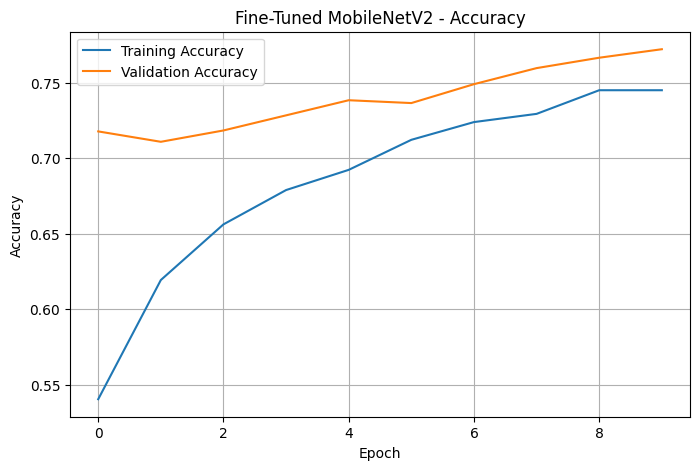

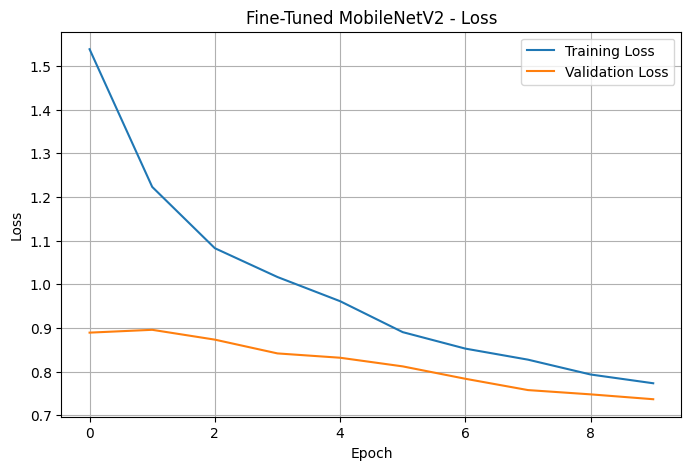

50/50 ━━━━━━━━━━━━━━━━━━━━ 11s 143ms/step

Fine-Tuned MobileNetV2 Evaluation Results on Validation Set
Accuracy : 0.7722
Precision: 0.7833
Recall   : 0.7722
F1-score : 0.7683

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.69      0.73        42
           1       0.86      0.88      0.87        43
          10       0.81      0.79      0.80        43
          11       0.78      0.95      0.86        42
          12       0.78      0.76      0.77        41
          13       0.69      0.76      0.72        41
          14       0.62      0.60      0.61        40
          15       0.68      0.74      0.71        43
          16       0.97      0.84      0.90        43
          17       0.81      0.90      0.85        42
          18       0.70      0.60      0.65        43
          19       0.76      0.72      0.74        43
           2       0.88      0.84      0.86        43
          20       0.93      0.90      0.92 

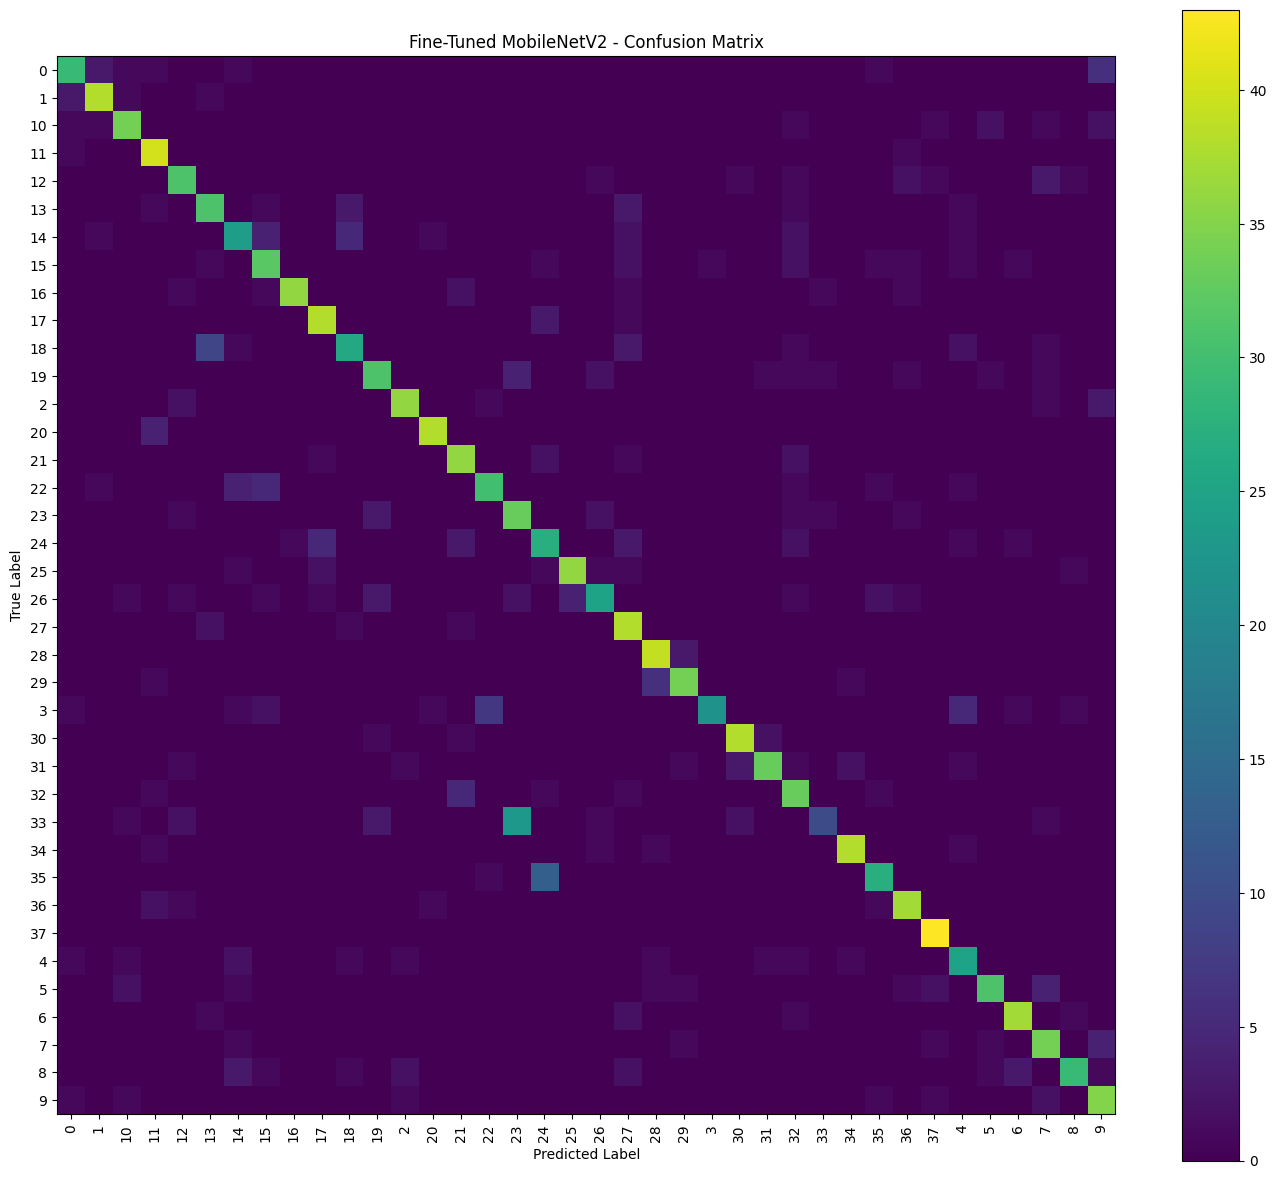

In [31]:
plot_training_curves(history_fine_tune, "Fine-Tuned MobileNetV2")
fine_tuned_results = evaluate_model(transfer_model, transfer_evaluation_generator, "Fine-Tuned MobileNetV2")


### Note on Test Set Structure

The dataset contains a Test folder with three images directly inside the folder, but it does not contain class-wise subfolders. Keras `flow_from_directory()` requires test images to be organized into class folders to calculate accuracy, precision, recall, F1-score, and confusion matrix.

Therefore, metric-based evaluation is performed using the validation set created from the training directory with a 15% validation split. The raw Test folder images are used only for prediction visualization, not for metric-based evaluation.


## 28. Final Model Comparison

,model,evaluation_set,accuracy,precision,recall,f1_score,training_time_seconds
3,Ablation Study - No Dropout,Validation Set,0.801001,0.843816,0.801001,0.815309,824.403500
1,Deeper CNN with Adam,Validation Set,0.775344,0.801044,0.775344,0.777990,1372.638737
5,Fine-Tuned MobileNetV2,Validation Set,0.772215,0.783272,0.772215,0.768316,549.286661
2,Deeper CNN with SGD,Validation Set,0.765957,0.796245,0.765957,0.774209,1459.636458
4,MobileNetV2 Feature Extraction,Validation Set,0.720275,0.730218,0.720275,0.716973,831.524092
0,Baseline CNN,Validation Set,0.688360,0.697488,0.688360,0.687039,1330.049950


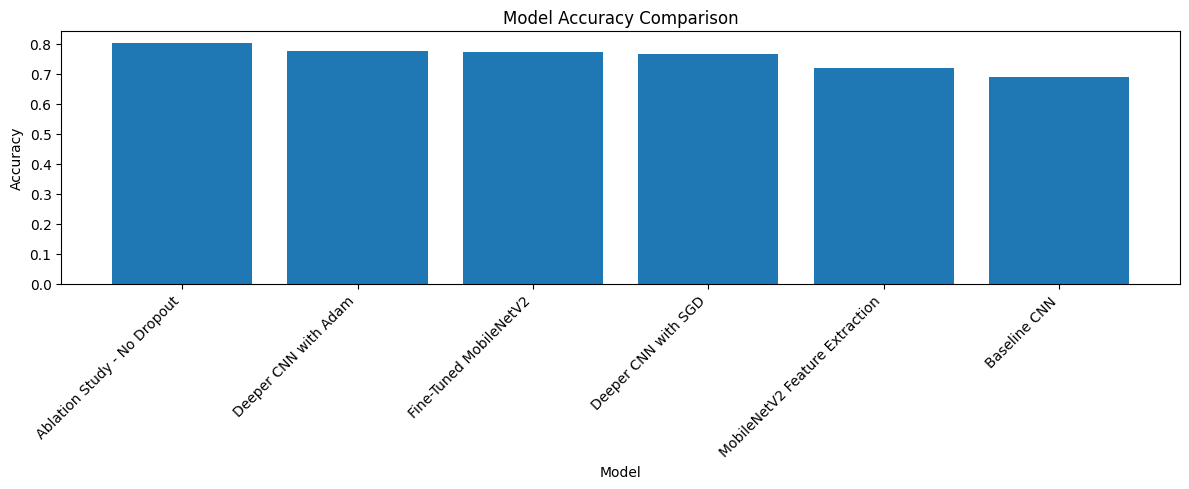

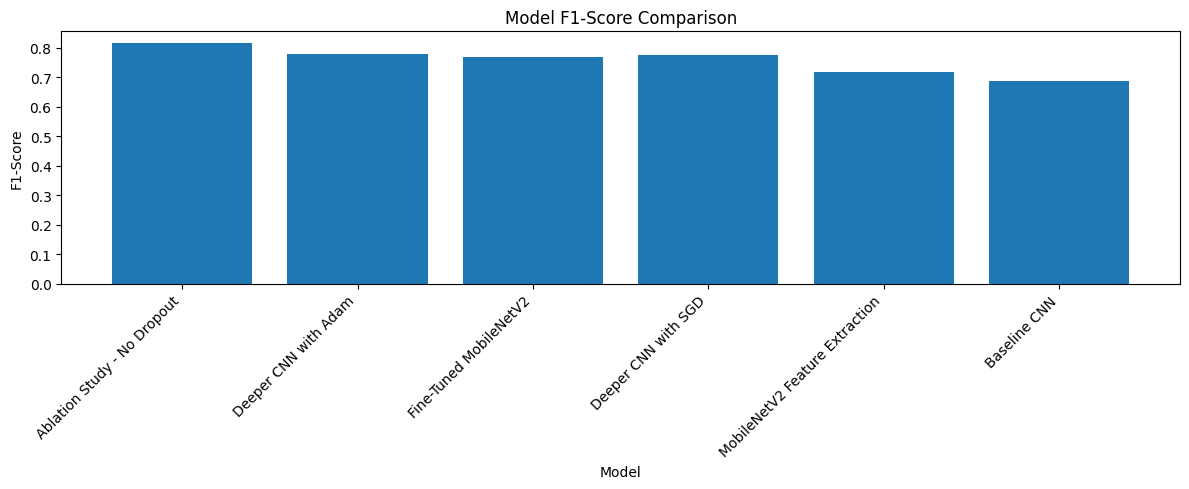

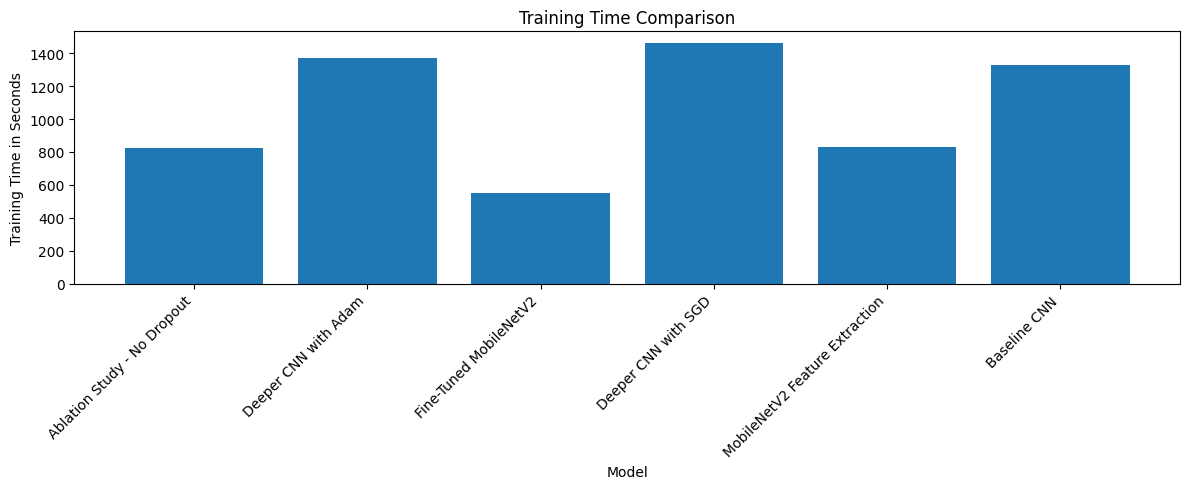

In [32]:
results = [
    baseline_results,
    deeper_adam_results,
    deeper_sgd_results,
    ablation_results,
    transfer_results,
    fine_tuned_results
]

results_df = pd.DataFrame(results)

training_times = {
    "Baseline CNN": baseline_time,
    "Deeper CNN with Adam": deeper_adam_time,
    "Deeper CNN with SGD": deeper_sgd_time,
    "Ablation Study - No Dropout": ablation_time,
    "MobileNetV2 Feature Extraction": transfer_time,
    "Fine-Tuned MobileNetV2": fine_tune_time
}

results_df["training_time_seconds"] = results_df["model"].map(training_times)
results_df = results_df.sort_values(by="accuracy", ascending=False)

display(results_df)

plt.figure(figsize=(12, 5))
plt.bar(results_df["model"], results_df["accuracy"])
plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df["model"], results_df["f1_score"])
plt.title("Model F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.bar(results_df["model"], results_df["training_time_seconds"])
plt.title("Training Time Comparison")
plt.xlabel("Model")
plt.ylabel("Training Time in Seconds")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


Raw Test Directory: /content/sign_language_dataset/Sign Language Detection/Test
Exists: True
Model used for raw test prediction: Ablation Study - No Dropout
Number of raw test images: 3


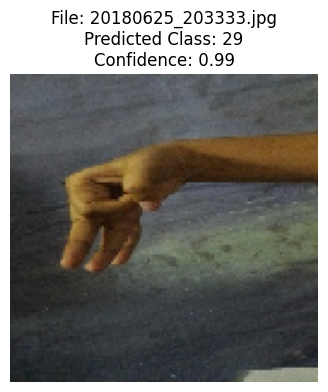

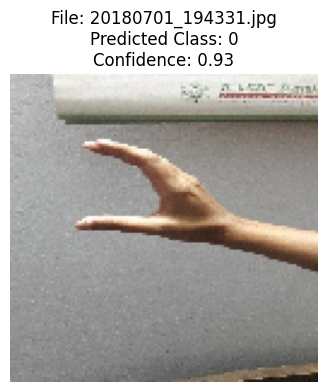

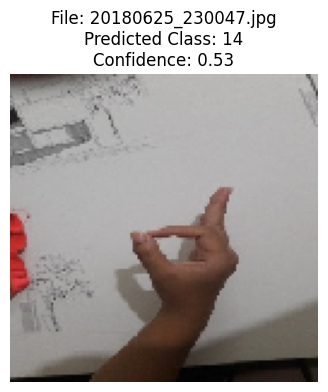

In [33]:
# Raw Test Folder Prediction
# This section predicts the three raw Test folder images.
# These images are not arranged class-wise, so this is prediction-only, not metric-based testing.

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

RAW_TEST_DIR = "/content/sign_language_dataset/Sign Language Detection/Test"

print("Raw Test Directory:", RAW_TEST_DIR)
print("Exists:", os.path.exists(RAW_TEST_DIR))

# Choose the best trained model available after running all cells.
# Based on the previous full run, ablation_model had the strongest validation performance.
if "ablation_model" in globals():
    prediction_model = ablation_model
    model_used = "Ablation Study - No Dropout"
elif "deeper_adam_model" in globals():
    prediction_model = deeper_adam_model
    model_used = "Deeper CNN with Adam"
elif "baseline_model" in globals():
    prediction_model = baseline_model
    model_used = "Baseline CNN"
else:
    prediction_model = None
    model_used = None

if prediction_model is None:
    print("No trained model found in current runtime.")
    print("Run the required model training cells first, or load a saved model.")
else:
    if not os.path.exists(RAW_TEST_DIR):
        print("Raw Test directory was not found.")
        print("Mount Drive and extract the dataset first.")
    else:
        test_images = [
            f for f in os.listdir(RAW_TEST_DIR)
            if f.lower().endswith((".jpg", ".jpeg", ".png", ".bmp", ".webp", ".gif"))
        ]

        print("Model used for raw test prediction:", model_used)
        print("Number of raw test images:", len(test_images))

        if len(test_images) == 0:
            print("No raw test images found.")
        else:
            for img_name in test_images:
                img_path = os.path.join(RAW_TEST_DIR, img_name)

                img = image.load_img(img_path, target_size=IMG_SIZE)
                img_array = image.img_to_array(img) / 255.0
                img_array = np.expand_dims(img_array, axis=0)

                prediction = prediction_model.predict(img_array, verbose=0)
                predicted_class_index = int(np.argmax(prediction))
                confidence = float(np.max(prediction))

                plt.figure(figsize=(4, 4))
                plt.imshow(img)
                plt.title(
                    f"File: {img_name}\n"
                    f"Predicted Class: {idx_to_class[predicted_class_index]}\n"
                    f"Confidence: {confidence:.2f}"
                )
                plt.axis("off")
                plt.show()


## 29. Sample Predictions

Change `best_model` after checking the final comparison table.


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 751ms/step


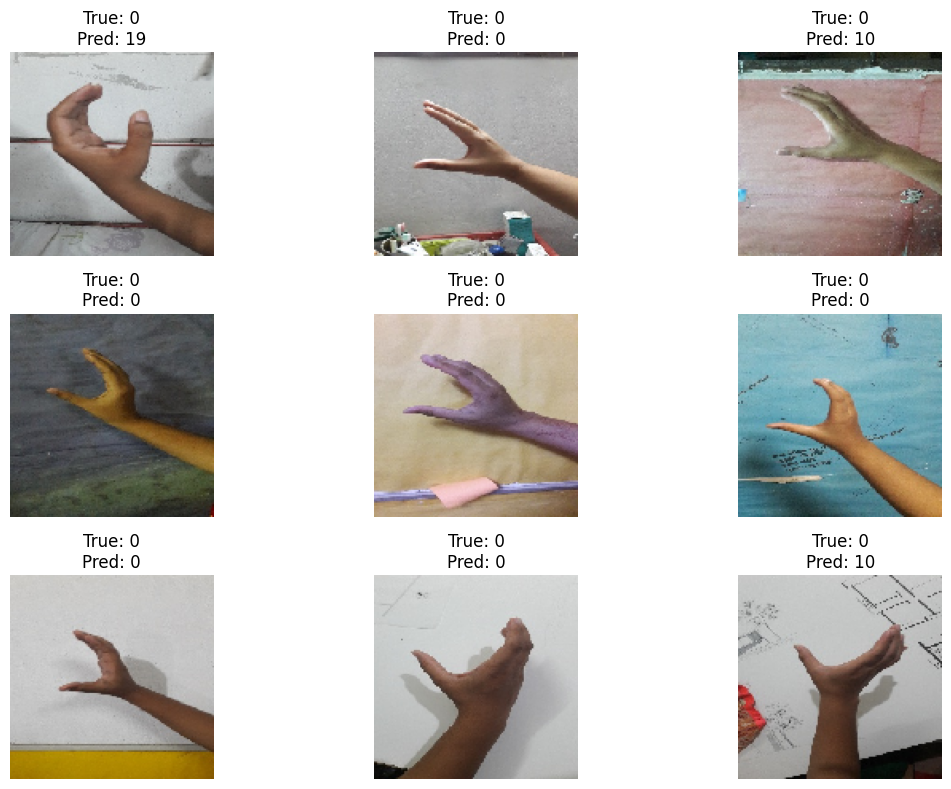

In [34]:
best_model = ablation_model
sample_generator = evaluation_generator

sample_generator.reset()
images, labels = next(sample_generator)

predictions = best_model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(12, 8))
for i in range(min(9, len(images))):
    plt.subplot(3, 3, i + 1)
    img = images[i]

    if img.min() < 0:
        img = (img + 1) / 2

    plt.imshow(img)
    plt.title(
        f"True: {idx_to_class[int(true_classes[i])]}\n"
        f"Pred: {idx_to_class[int(predicted_classes[i])]}"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()


## 30. Report Notes

Use these points in your report after running the notebook:

- The baseline CNN was trained for a maximum of 25 epochs with early stopping.
- If the baseline stopped before 25 epochs, explain that early stopping prevented unnecessary training once validation loss stopped improving.
- The deeper CNN had more convolutional layers and used Batch Normalization and Dropout.
- Adam and SGD were compared using the same deeper architecture.
- The ablation model removed Dropout to test the importance of regularization.
- MobileNetV2 was used for transfer learning because it is lightweight and has pretrained ImageNet feature extraction capability.
- If the test folder has 0 images, state that model evaluation was performed on the validation set.
- Discuss class similarity, lighting changes, background noise, and gesture orientation as possible causes of error.
